<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase3/NEU_Surface_Defect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement 
You are a junior ML engineer at
SmartForge Manufacturing. The production line images thousands of steel strips
every day. Manual visual inspection is slow, inconsistent, and misses subtle
defects that cause costly downstream failures. The engineering team needs two
things:
1. a model that can identify which type of defect is present, and 
2. evidence that the model is robust enough to handle real production variability
(different lighting, orientations, and surface conditions). Your job is to
build and harden that model using PyTorch.

### Setup 

In [4]:
# imports
import torch 
import torch.nn as nn 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np 
import matplotlib.pyplot as plt 
import copy

In [5]:
tfm = transforms.Compose([
    transforms.Resize((200,200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])
train_ds = datasets.ImageFolder('NEU-DET/train/images',transform=tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images',transform=tfm)


In [6]:
print("Number of images:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

Number of images: 1440
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

In [8]:
test_loader = DataLoader(
    test_ds,        # was train_ds — bug
    batch_size=32,
    shuffle=False   # no need to shuffle validation/test data
)

In [9]:
tfm = transforms.Compose([
    transforms.Resize((200,200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])
train_ds = datasets.ImageFolder('NEU-DET/train/images', transform=tfm)
test_ds = datasets.ImageFolder('NEU-DET/validation/images', transform=tfm)

print("Number of images:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Number of images: 1440
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [10]:
train_loader

# Part 0 : NN Foundations 

### 1. Implement a simple 2-layer neural network from scratch
using nn.Module no nn.Sequential shortcuts. Define __init__ and forward
explicitly.


Build: 

1. `__init__ `: explicitly defines layers as attribute 
2. `x.view(x.size(0), -1)` inside forward  since images come in as (batch_size, 3, 200, 200) from the DataLoader, and a Linear layer expects a flat 2D input (batch_size, features),flatten every dimension except the batch dimension. 

3. No activation after fc2 the raw logits are returned directly, because nn.CrossEntropyLoss expects raw logits and applies log_softmax internally. Adding a Softmax here yourself would double-apply it and break training.

In [7]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size ):
        super().__init__()

        #layer 1 
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = X.view(X.size(0), -1) 
        X = self.fc1(X)
        X = self.relu(X)
        X = self.fc2(X)
        return X


##### Build
1. `__init__` explicitly defines layers ass attributes

2. x.view(x.size(0),-1 ) the image comes in ass (batch_ize, 3, 200,200), from the dataloader and a linear layer expects a flat 2D input `(batch_size, features)`

3. No activattion after `fc2`: the raw logits are retrned directky, becase nn.CrossEntropy loss expects rawlogits, and applies softmax internally 

### 2. Activation functions: swap ReLU for Sigmoid in your hidden layer and compare convergence over 20 epochs. What do you notice?

In [37]:
class Simple2LayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation = "relu"):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU() if activation == "relu" else nn.Sigmoid()  # to decrease redundanct code
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1) #compress to 2d
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x 

In [52]:
def train_model(model, optimizer, train_loader, criterion, epochs=20):
    loss_hist = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for image, label in train_loader:
            output = model(image)
            loss = criterion(output, label)
            optimizer.zero_grad() # clears the gradients from the previous step ;pt accumulates grad by efault
            loss.backward() #backpropagation
            optimizer.step() #upates the model weights 
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_hist.append(avg_loss)
        print(f"Epochs {epoch+1}/ {epochs}, Loss : {avg_loss}")
    return loss_hist

In [11]:
# model parameters 
input_size = 3 * 200 * 200
# 3 for color RGB and 200x200 is image hxw
hidden_size = 128 
num_classes = len(train_ds.classes)
criterion = nn.CrossEntropyLoss()
epochs = 20 

In [57]:
# for reprodiuciblity ; why always 42--Not always 42; justa  lucky number; can use any number 
torch.manual_seed(42 )
# for relu 
model_relu = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "relu")

In [58]:
#reset seed to the same vlaue so model_sigmoid gets identical initital weights 
torch.manual_seed(42)
model_sigmoid = Simple2LayerNN(input_size, hidden_size, num_classes, activation = "sigmoid")

In [59]:
# seperate optimizer for each model, adam tracks per-parameter state, so eacch model needs its own instance 
opt_relu = torch.optim.Adam(model_relu.parameters(), lr=0.001)
opt_sigmoid = torch.optim.Adam(model_sigmoid.parameters(), lr=0.001)


In [60]:
print("Training with ReLU.......")
loss_relu = train_model(model_relu, opt_relu, train_loader, criterion, epochs)


Training with ReLU.......
Epochs 1/ 20, Loss : 14.745438967810736
Epochs 2/ 20, Loss : 8.657253779305352
Epochs 3/ 20, Loss : 6.463003412882487
Epochs 4/ 20, Loss : 5.278574249479505
Epochs 5/ 20, Loss : 3.042806702189975
Epochs 6/ 20, Loss : 2.956722068786621
Epochs 7/ 20, Loss : 3.8283591588338215
Epochs 8/ 20, Loss : 4.0359620852602855
Epochs 9/ 20, Loss : 2.1650445030795202
Epochs 10/ 20, Loss : 1.726602178812027
Epochs 11/ 20, Loss : 1.5394811507728365
Epochs 12/ 20, Loss : 1.5329998119009867
Epochs 13/ 20, Loss : 1.2566487060652838
Epochs 14/ 20, Loss : 2.36754211584727
Epochs 15/ 20, Loss : 1.3318881195452479
Epochs 16/ 20, Loss : 0.8513764441013336
Epochs 17/ 20, Loss : 0.8888723303874334
Epochs 18/ 20, Loss : 1.1629293660322826
Epochs 19/ 20, Loss : 1.1246533311075635
Epochs 20/ 20, Loss : 0.8246496273411645


In [63]:
print("Training with sigmoid........")
loss_sigmoid = train_model(model_sigmoid, opt_sigmoid, train_loader, criterion, epochs)

Training with sigmoid........
Epochs 1/ 20, Loss : 1.6509633170233833
Epochs 2/ 20, Loss : 1.5487802240583632
Epochs 3/ 20, Loss : 1.5068914863798353
Epochs 4/ 20, Loss : 1.4785277605056764
Epochs 5/ 20, Loss : 1.4741892947090998
Epochs 6/ 20, Loss : 1.4461919811036852
Epochs 7/ 20, Loss : 1.4169582658343844
Epochs 8/ 20, Loss : 1.4069631576538086
Epochs 9/ 20, Loss : 1.3878456777996486
Epochs 10/ 20, Loss : 1.3770901891920302
Epochs 11/ 20, Loss : 1.3592094315422907
Epochs 12/ 20, Loss : 1.3546625667148167
Epochs 13/ 20, Loss : 1.3387040535608927
Epochs 14/ 20, Loss : 1.3158487108018664
Epochs 15/ 20, Loss : 1.304413980907864
Epochs 16/ 20, Loss : 1.2901036977767943
Epochs 17/ 20, Loss : 1.2918552902009752
Epochs 18/ 20, Loss : 1.2972790718078613
Epochs 19/ 20, Loss : 1.2890637556711833
Epochs 20/ 20, Loss : 1.2961081796222262


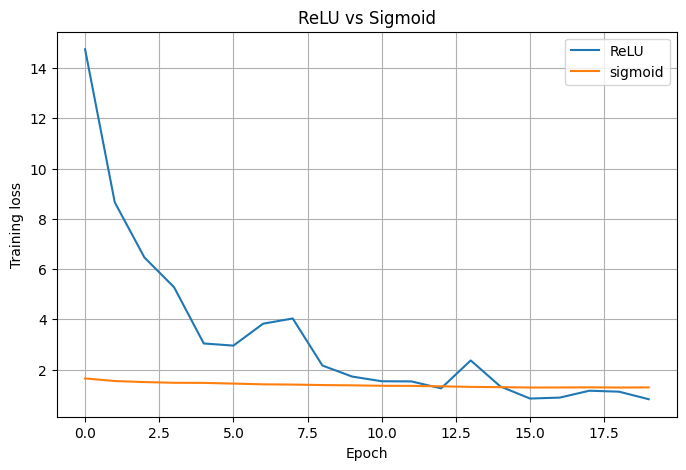

In [79]:
plt.figure(figsize=(8,5))
plt.plot(loss_relu, label="ReLU")
plt.plot(loss_sigmoid, label= "sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("ReLU vs Sigmoid")
plt.grid()
plt.legend()
plt.show()

### Observations
ReLU converged faster and reach a lower loss within 20 epochs 
Sigmoid converged more lowly, and the loss curve look almost flat and at last it dropped littlebit 

whay did it happened 
1. vanishing gradients : sigmoid squashes any intput to `(0,1)`. Its derivative hass a max value of only 0.25(at x =0), and get close to 0 when the input is large or large negative

2. ReLU avoud this for active neurons.ReLU's derivative is either 0(for negative )or 1(for+ve), no squashing and shriniking gradeints



### 3.Loss function choice: train with nn.CrossEntropyLoss. Why is this preferred over nn.MSELoss for multi-class defect classification?

1. It fits the problem. `CrossEntropyLoss` compares predicted probablities to the correct class. MSE compares raw numbers, it doeesn't understand categories so it treats defect labels as if they had numeric distance between them

2. It learns faster when the model is wrong:`CrossEntropyLoss` gives a strong gradient(correction signals) when the prediction is confidently wrong, pusshing the model to fix itself quickly.MSEs gradient shrinks to almost zero in that same ssituation, so the model barely learns from its biggest mistakes 

3. It's the standatd, numerically stable choiocs. CrossEntropyLoss orks directly on raw model output (logits) and handles the math safely under the hood. MSE would need extra manual steps and doesnot give better results 

### 4.Optimizer comparison: train the same network three times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss curves on one graph. Which converges fastest? Estimate the GPU memory each optimizer requires for this model.


In [68]:
# using the same Simple2LayerNN 
base_model = Simple2LayerNN(input_size, hidden_size, num_classes)
# deepcopy creates a completely independent copy of the model — including its own separate weight tensors in memory, not references to the original
model_sgd = copy.deepcopy(base_model)
model_sgd_momentum = copy.deepcopy(base_model)
model_adam = copy.deepcopy(base_model)

opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr =0.001)
opt_sgd_mom= torch.optim.SGD(model_sgd_momentum.parameters(), lr =0.001, momentum=0.9)
opt_adam = torch.optim.Adam(model_adam.parameters(), lr =0.001)

In [69]:
print("Training with SGD...")
loss_sgd = train_model(model_sgd, opt_sgd, train_loader, criterion, epochs)

Training with SGD...
Epochs 1/ 20, Loss : 1.5575754589504667
Epochs 2/ 20, Loss : 1.433606391482883
Epochs 3/ 20, Loss : 1.3619900438520642
Epochs 4/ 20, Loss : 1.3131279733445909
Epochs 5/ 20, Loss : 1.2746777892112733
Epochs 6/ 20, Loss : 1.2349453820122613
Epochs 7/ 20, Loss : 1.2048444906870523
Epochs 8/ 20, Loss : 1.1767536640167235
Epochs 9/ 20, Loss : 1.1499072551727294
Epochs 10/ 20, Loss : 1.1280692405170865
Epochs 11/ 20, Loss : 1.1064664721488953
Epochs 12/ 20, Loss : 1.0866749114460414
Epochs 13/ 20, Loss : 1.0668830672899883
Epochs 14/ 20, Loss : 1.048075066672431
Epochs 15/ 20, Loss : 1.030569346745809
Epochs 16/ 20, Loss : 1.0160296943452622
Epochs 17/ 20, Loss : 0.9991463555230035
Epochs 18/ 20, Loss : 0.9848989791340298
Epochs 19/ 20, Loss : 0.9710209740532769
Epochs 20/ 20, Loss : 0.9570834027396308


In [70]:
print("Training with SGD + Momentum...")
losss_sgd_mom = train_model(model_sgd_momentum, opt_sgd_mom, train_loader, criterion, epochs)

Training with SGD + Momentum...
Epochs 1/ 20, Loss : 1.519517911805047
Epochs 2/ 20, Loss : 1.2351221601168314
Epochs 3/ 20, Loss : 1.159636804792616
Epochs 4/ 20, Loss : 1.0072172734472487
Epochs 5/ 20, Loss : 0.9270462393760681
Epochs 6/ 20, Loss : 0.8173232403066423
Epochs 7/ 20, Loss : 0.7880279342333476
Epochs 8/ 20, Loss : 0.7519357336892022
Epochs 9/ 20, Loss : 0.6615821441014608
Epochs 10/ 20, Loss : 0.6431176079644098
Epochs 11/ 20, Loss : 0.5751072605450948
Epochs 12/ 20, Loss : 0.5541879726780785
Epochs 13/ 20, Loss : 0.5769372741381328
Epochs 14/ 20, Loss : 0.4912715256214142
Epochs 15/ 20, Loss : 0.47878040969371793
Epochs 16/ 20, Loss : 0.4401512291696337
Epochs 17/ 20, Loss : 0.4207550754149755
Epochs 18/ 20, Loss : 0.3777798722187678
Epochs 19/ 20, Loss : 0.3843401726749208
Epochs 20/ 20, Loss : 0.3567899003624916


In [71]:
print("Traiing with adam..")
losss_adam = train_model(model_adam, opt_adam, train_loader, criterion, epochs)

Traiing with adam..
Epochs 1/ 20, Loss : 12.813657304975722
Epochs 2/ 20, Loss : 5.807154907120599
Epochs 3/ 20, Loss : 7.556875117619833
Epochs 4/ 20, Loss : 4.604156192143758
Epochs 5/ 20, Loss : 4.0946977456410725
Epochs 6/ 20, Loss : 2.6452882236904567
Epochs 7/ 20, Loss : 3.354050397872925
Epochs 8/ 20, Loss : 2.1893773489528234
Epochs 9/ 20, Loss : 2.962486974398295
Epochs 10/ 20, Loss : 2.1103033122089174
Epochs 11/ 20, Loss : 1.702955922153261
Epochs 12/ 20, Loss : 3.078392987118827
Epochs 13/ 20, Loss : 2.0190515677134195
Epochs 14/ 20, Loss : 1.2503975186083052
Epochs 15/ 20, Loss : 1.023332812057601
Epochs 16/ 20, Loss : 1.4145230849583943
Epochs 17/ 20, Loss : 0.8975510146882799
Epochs 18/ 20, Loss : 0.7577093377709389
Epochs 19/ 20, Loss : 0.8282708078622818
Epochs 20/ 20, Loss : 0.7887951993279987


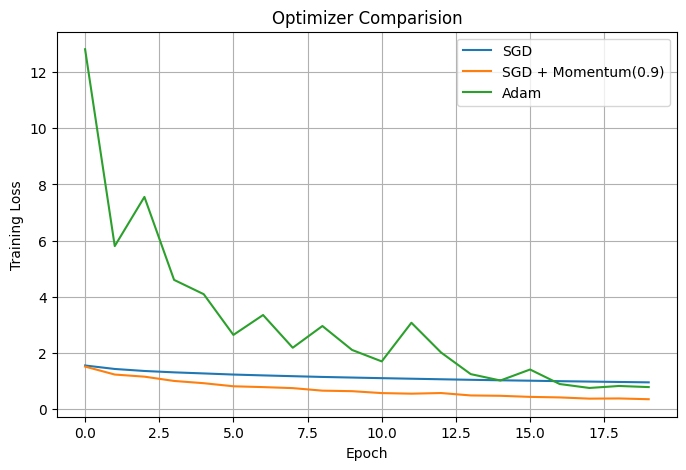

In [75]:
plt.figure(figsize = (8,5))
plt.plot(loss_sgd, label = "SGD")
plt.plot(losss_sgd_mom, label = "SGD + Momentum(0.9)")
plt.plot(losss_adam, label = "Adam")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparision")
plt.grid(True)
plt.legend()
plt.show()

Adam Spiked and oscilated instead of converging smoothly, while SGD and SGD + momentum decresed steadilt but slowly. This is likely because Adam's adaptive learning rate overreacted to the large, unnormalized input 

### 5. Training stability: add nn.BatchNorm1d after your hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation loss. Explain why the technique produces the effect you observe.

In [12]:
class Simple2LayerNN_BN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, p =0.3):
        super().__init__()
        self.fc1 =nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.fc2(x)
        return x 

In [13]:
class Simple2LayerNN_Dropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, p =0.3):
        super().__init__()
        self.fc1 =nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2()
        return x 

In [16]:
def train_with_val(model, optimizer,train_loader, val_loader, criterion , epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()  #BN use batch stats, Dropout is active
        running_loss = 0.0
        for image, label in train_loader:
            output = model(image)
            loss = criterion(output, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)  # BUG: avg_loss was never computed before print
        train_losses.append(avg_loss)
        

        model.eval() 
        val_loss = 0.0
        with torch.no_grad():
            for image, label in val_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    return train_losses, val_losses

In [17]:
model_bn = Simple2LayerNN_BN(input_size, hidden_size, num_classes)
opt_bn = torch.optim.Adam(model_bn.parameters(), lr=0.001)
train_loss_bn, val_loss_bn = train_with_val(model_bn, opt_bn, train_loader, test_loader, criterion, epochs=20)

Epoch 1/20, Train Loss: 1.5186, Val Loss: 1.5399
Epoch 2/20, Train Loss: 1.2749, Val Loss: 1.3837
Epoch 3/20, Train Loss: 1.1431, Val Loss: 1.3514
Epoch 4/20, Train Loss: 1.0513, Val Loss: 1.4322
Epoch 5/20, Train Loss: 0.9687, Val Loss: 1.2099
Epoch 6/20, Train Loss: 0.9155, Val Loss: 1.2350
Epoch 7/20, Train Loss: 0.8456, Val Loss: 1.2333
Epoch 8/20, Train Loss: 0.8114, Val Loss: 1.1921
Epoch 9/20, Train Loss: 0.7415, Val Loss: 1.3339
Epoch 10/20, Train Loss: 0.7181, Val Loss: 1.3604
Epoch 11/20, Train Loss: 0.6724, Val Loss: 1.1585
Epoch 12/20, Train Loss: 0.6096, Val Loss: 1.3019
Epoch 13/20, Train Loss: 0.6041, Val Loss: 1.0998
Epoch 14/20, Train Loss: 0.6164, Val Loss: 1.4586
Epoch 15/20, Train Loss: 0.5781, Val Loss: 1.3179
Epoch 16/20, Train Loss: 0.5903, Val Loss: 1.1666
Epoch 17/20, Train Loss: 0.5154, Val Loss: 0.9916
Epoch 18/20, Train Loss: 0.5268, Val Loss: 1.1804
Epoch 19/20, Train Loss: 0.5258, Val Loss: 1.6760
Epoch 20/20, Train Loss: 0.4959, Val Loss: 1.0988
